In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

from PyAstronomy import pyasl
import pysynphot as S

from scipy.signal import savgol_filter

from matplotlib.gridspec import GridSpec

import re

import pandas as pd

from astropy.time import Time

#from astroquery.gaia import Gaia
from astroquery.utils.tap.core import TapPlus
from dust_extinction.parameter_averages import G23

import os

from tqdm import trange

from astropy import units as u, constants as c

import time

import pyphot
from pyphot import unit
lib = pyphot.get_library()

from astropy.wcs import WCS

#from multiprocessing import Pool
from multiprocess import Pool

import emcee

from astropy.table import Table
from astropy.convolution import convolve, Box1DKernel

from joblib import Parallel, delayed

import warnings
from astropy.utils.exceptions import AstropyWarning

from scipy.interpolate import LSQUnivariateSpline

CB = ['#377eb8','#ff7f00','#228B22','#f781bf', 
      '#a65628','#984ea3','#999999','#c43a1c', 
      '#dede00','#222222','#DD8F07']

def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    rgb = colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])
    hexcol = mc.to_hex(rgb)
    return hexcol

lcolors = []
for e in CB:
    el = lighten_color(e,amount=0.5)
    lcolors.append(el)
    
dcolors = []
for e in CB:
    ed = lighten_color(e,amount=1.0)
    dcolors.append(ed)
    
mpl.rcParams.update(
     {# Use mathtext, not LaTeX
     'text.usetex': False,
     'axes.formatter.use_mathtext': True,
     # Set the fonts
     'font.family': 'STIXGeneral',
     'mathtext.fontset': 'cm',
     # Use ASCII minus
     'axes.unicode_minus': False,
    'axes.linewidth':1.5
})

wd_dilfact_file = pd.read_csv('wd_dilution_fact.csv')
wd_dilfact_wave = wd_dilfact_file.waves.values
wd_dilfact_fact = wd_dilfact_file.dil_fact.values


/Applications/Anaconda/anaconda3/lib/python3.11/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/Applications/Anaconda/anaconda3/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


# Spectra

In [2]:
def median_norm(waves, fluxes, window_angs = 15, top_mean = 20, poly_deg = 5, smooth_wave = 1.0, do_smooth = False, 
               norm_show = False):
    
    select = abs(fluxes)>0
    wave = waves[select]
    flux = fluxes[select]
    
    if do_smooth:
        smooth_N = int(smooth_wave/np.mean(np.diff(wave)))
    else:
        smooth_N = 1.0
    kernel = Box1DKernel(smooth_N)
    flux_smoothed = convolve(flux, kernel)
    
    window = int(window_angs/np.mean(np.diff(wave)))
        
    norm_wave = np.zeros(len(wave)-window)
    norm_flux = np.zeros(len(wave)-window)
    
    top_values = []
    top_waves = []
    
    for i in range(int(window/2), int(len(wave)-window/2), int(window/8)):
        
        top_30 = np.partition(flux_smoothed[int(i-window/2):int(i+window/2)], -top_mean)[-top_mean:]
        median_cont_med_spec = np.median(top_30)
        
        top_waves.append(wave[i])
        top_values.append(median_cont_med_spec)
        
    top_waves = np.array(top_waves)
    top_values = np.array(top_values)
    
    cont_vals = np.interp(wave, top_waves, top_values)
    
    if norm_show:
        plt.plot(wave, flux)
        plt.scatter(top_waves, top_values, s=10, c='red')
        plt.plot(wave, cont_vals, c='red')
        plt.show()
    
    return wave, flux/cont_vals


def merge_orders(filename, wave_cut = 20, order_uplim = 25, wave_low = 3000.0, wave_up = 9000,
                norm_show = False):
    
    hdul = fits.open(filename)
    
    wave = hdul[0].data[0][0].copy()
    normalized_flux = hdul[0].data[3][0].copy()
    
    resol = np.mean(np.diff(wave))
    num_index = int(wave_cut/resol)

    normalized_flux[:num_index] = 0.0
    normalized_flux[-num_index:] = 0.0
    
    wave, normalized_flux = median_norm(wave, normalized_flux, do_smooth=True, norm_show=norm_show)
    
    for i in range(1,order_uplim):
        
        wave_old = wave.copy()
        normalized_flux_old = normalized_flux.copy()
        
        wave_new = hdul[0].data[0][i].copy()
        wave = np.concatenate((wave_old, wave_new), axis = 0)
        
        wave_sort_ind = np.argsort(wave)
        wave = wave[wave_sort_ind]
                
        resol = np.mean(np.diff(wave_new))
        
        num_index = int(wave_cut/resol)
        
        normalized_flux_new = hdul[0].data[3][i].copy()
        normalized_flux_new[:num_index] = 0.0
        normalized_flux_new[-num_index:] = 0.0
        
        wave_new, normalized_flux_new = median_norm(wave_new, normalized_flux_new, do_smooth=True, norm_show=norm_show)
        
        flux_interp_old = np.interp(wave, wave_old, normalized_flux_old, left =0, right = 0)
        flux_interp_new = np.interp(wave, wave_new, normalized_flux_new, left =0, right = 0)
        
        normalize_factor = ((flux_interp_old!=0.0) + 0.0) + ((flux_interp_new!=0.0) + 0.0)
        normalize_factor[normalize_factor==0.0] = 1.0
        
        normalized_flux = (flux_interp_old + flux_interp_new)/normalize_factor
                
    select = (wave<wave_up) & (wave>wave_low)
            
    return wave[select], normalized_flux[select]

In [12]:
def read_and_display(wave_obj, normalized_flux_obj, star_model_file, rv, vsini, nf, wave_range,
                    show = True, model = 'coelho', buffer = 50.0, norm_show = False):
    
    if model == 'coelho':
        coelho = pd.read_csv(star_model_file,
                                 skiprows = 8, header = None, delim_whitespace = True)

        coelho = coelho[(coelho[0]<wave_range[1]+buffer)&(coelho[0]>wave_range[0]-buffer)]

        coelho_wave_pre_resampled = coelho[0].values + rv*coelho[0].values/3e5
        coelho_flux_pre_resampled = coelho[1].values
        
    if model == 'bosz':
        
        parent_dir = './bosz_models/r50000/m+0.00/'
        
        bosz_wave = pd.read_csv('./bosz_models/r50000/bosz2024_wave_r50000.txt', header = None)[0].values
        select_bosz_wave = (bosz_wave<(wave_range[1]+buffer))&(bosz_wave>(wave_range[0]-buffer))
        
        coelho_wave_pre_resampled = bosz_wave[select_bosz_wave]
        coelho_flux_pre_resampled = pd.read_csv(star_model_file, header = None,
                  delim_whitespace = True)[0].values[select_bosz_wave]
        

        wave_res = np.min(np.diff(coelho_wave_pre_resampled))
        coelho_wave = np.arange(coelho_wave_pre_resampled[0], coelho_wave_pre_resampled[-1]+wave_res,
                               wave_res)

        coelho_flux = np.interp(coelho_wave, coelho_wave_pre_resampled, coelho_flux_pre_resampled)

        coelho_flux_broadened = pyasl.rotBroad(coelho_wave, coelho_flux, 0.4, vsini)

        coelho_wave_norm, coelho_flux_norm = median_norm(coelho_wave, coelho_flux_broadened, 
                                                         norm_show=norm_show)

        coelho_flux_norm = coelho_flux_norm*nf

        coelho_wave_norm = coelho_wave_norm + rv*coelho_wave_norm/3e5
        
    if model == 'none':
        
        coelho_wave_norm = []
        coelho_flux_norm = []
    
    select_obj = (wave_obj<wave_range[1])&(wave_obj>wave_range[0])
        
    wave_obj_select = wave_obj[select_obj]
    normalized_flux_obj_select = normalized_flux_obj[select_obj]
    
    if show:
        
        plt.figure(figsize = (10,5))
        
        plt.plot(wave_obj_select, normalized_flux_obj_select, c='k', alpha = 0.6)
        plt.plot(coelho_wave_norm, coelho_flux_norm, c='C0', linewidth = 2.0)
        plt.xlim(min(wave_obj_select), max(wave_obj_select))
        
        plt.gca().tick_params(which='both',direction='in',top=True,right=True,labelsize=16,labelbottom = True, width=2, labelleft=True)
        
        plt.ylabel(r'Relative Flux', fontsize = 18)
        plt.xlabel(r'Wavelength $(\AA)$', fontsize = 18)
        
        plt.show()
        
    return wave_obj_select, normalized_flux_obj_select, coelho_wave_norm, coelho_flux_norm
        

In [4]:
GAIA_TAP_URL = 'https://gea.esac.esa.int/tap-server/tap'
gaia = TapPlus(url=GAIA_TAP_URL)

def search_gaia(desgn):

    query = f"""
    SELECT *
    FROM gaiadr3.gaia_source
    WHERE designation = '{desgn}'
    AND parallax IS NOT NULL
    """

    Gaia.ROW_LIMIT = -1

    gaia = TapPlus(url=GAIA_TAP_URL)
    job = gaia.launch_job_async(query)
    result = job.get_results()
        
    bprp = result['bp_rp'].value
    Teff = 10**(3.999-0.654*(bprp)+0.709*(bprp**2)-0.316*(bprp**3))
    
    teff_avg = (result['teff_gspphot'].value[0] + Teff[0])/2.0
    
    print('Teff: ',Teff[0])
    print('teff_gspphot: ',result['teff_gspphot'].value[0])
    print('Teff avg: ',teff_avg)
    print('Ra, Dec: ',result['ra'].value[0], result['dec'].value[0])
    print('PMRa, PMDec: ',result['pmra'].value[0], result['pmdec'].value[0])
    print('PM: ',result['pm'].value[0])
    print('Gmag: ',result['phot_g_mean_mag'].value[0])
    print('Distance: ',1000.0/result['parallax'].value[0])
    
    return result, Teff[0], result['teff_gspphot'].value[0], teff_avg


In [5]:
def filename_to_mjd(filename):
    # Regex to capture YYYYMMDD_UTXX:XX:XX.xxx
    match = re.search(r'(\d{8}_UT\d{2}:\d{2}:\d{2}\.\d+)', filename)
    if not match:
        raise ValueError(f"Could not find timestamp in {filename}")
    
    timestamp_str = match.group(1)  # e.g. '20250617_UT00:10:55.496'
    
    # Remove 'UT' and parse into ISO-like format
    date_str, time_str = timestamp_str.split('_UT')
    iso_str = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]} {time_str}"
    
    # Convert to astropy Time and MJD
    t = Time(iso_str, format='iso', scale='utc')
    return t.mjd

def read_coadd(gaia_id_num, data_files_path = './uv_feros/', wave_range = [5300, 5700],
              show = True, norm_show = False):
    
    data_files = os.listdir(data_files_path)
    
    count = 0.0
    waves = []
    fluxes = []
    mjds = []
    for data_file in data_files:
        
        if gaia_id_num in data_file:
            
            mjds.append(filename_to_mjd(data_file))
            
            count+=1.0
            
            wave, flux = merge_orders('./uv_feros/{}'.format(data_file), norm_show=norm_show)
                        
            print('./uv_feros/{}'.format(data_file))
            
            waves.append(wave)
            fluxes.append(flux)
            
            if count==1.0:
                wave_ref = wave.copy()
                flux_coadd = flux.copy()
            else:
                flux_interp = np.interp(wave_ref, wave, flux)
                flux_coadd = flux_coadd + flux_interp
                
    print('Number of Coadds: ',count)
    
    if show:
        select = (wave_ref<wave_range[1])&(wave_ref>wave_range[0])
        plt.plot(wave_ref[select], flux_coadd[select]/count)
        plt.xlim(wave_range[0], wave_range[1])
        plt.show()
        
        for (wave, flux) in zip(waves, fluxes):
            select = (wave<wave_range[1])&(wave>wave_range[0])
            plt.plot(wave[select], flux[select])
            plt.xlim(wave_range[0], wave_range[1])
        plt.show()
                
    return wave_ref, flux_coadd/count, waves, fluxes, mjds

In [6]:
def get_cks_broadened(filename, rv, vsini, order = -1, ld = 0.4):
    
    hdulist = fits.open(filename)
    galah_flux_file = hdulist[0].data[order]
    galah_waves_file = hdulist[2].data[order]
    
    galah_waves = np.arange(min(galah_waves_file), max(galah_waves_file), min(np.diff(galah_waves_file)))
    galah_flux = np.interp(galah_waves, galah_waves_file, galah_flux_file)
    
    galah_flux_broadened = pyasl.rotBroad(galah_waves, galah_flux, ld, vsini)
    galah_waves = galah_waves * (1 + rv/3e5)
    return galah_waves, galah_flux_broadened

def get_galah_broadened(filename, rv, vsini, ld = 0.4, source = 'script'):
    galah_spec = fits.open(filename)
    
    if source=='web':
        galah_wcs = WCS(galah_spec[0].header)
        galah_waves = []
        for i in range(4096):
            galah_waves.append(galah_wcs.pixel_to_world(i).value)
        galah_waves = np.array(galah_waves)
    else:
        galah_waves = galah_spec[1].data
    galah_flux = galah_spec[0].data
    galah_flux_broadened = pyasl.rotBroad(galah_waves, galah_flux, ld, vsini)
    galah_waves = galah_waves * (1 + rv/3e5)
    return galah_waves, galah_flux_broadened

def get_synspec_broadened(filename, rv, vsini, ld = 0.4):
    
    synspec_df = pd.read_csv(filename)
    
    galah_flux_file = synspec_df.flux.values
    galah_waves_file = synspec_df.waveobs.values
    
    galah_waves = np.arange(min(galah_waves_file), max(galah_waves_file), min(np.diff(galah_waves_file)))
    galah_flux = np.interp(galah_waves, galah_waves_file, galah_flux_file)
    
    galah_flux_broadened = pyasl.rotBroad(galah_waves, galah_flux, ld, vsini)
    galah_waves = galah_waves * (1 + rv/3e5)
    
    
    
    return galah_waves, galah_flux_broadened

def get_synspec_broadened_grid(filename, rv, vsini, ld = 0.4, galah_waves = np.arange(450, 650, 0.01)):
    
    synspec_df = fits.open(filename)
    
    galah_flux = synspec_df[0].data
    
    galah_flux_broadened = pyasl.rotBroad(galah_waves*10, galah_flux, ld, vsini)
    galah_waves = galah_waves * (1 + rv/3e5)
    
    
    
    return galah_waves*10, galah_flux_broadened

./uv_feros/uv_TARG3499149202247569536_20250617_UT00:10:55.496_sp.fits
./uv_feros/uv_TARG3499149202247569536_20250810_UT23:45:24.621_sp.fits
./uv_feros/uv_TARG3499149202247569536_20250517_UT00:57:11.039_sp.fits
./uv_feros/uv_TARG3499149202247569536_20250707_UT01:05:16.869_sp.fits
./uv_feros/uv_TARG3499149202247569536_20250426_UT06:17:39.831_sp.fits
./uv_feros/uv_TARG3499149202247569536_20250522_UT02:06:42.735_sp.fits
Number of Coadds:  6.0


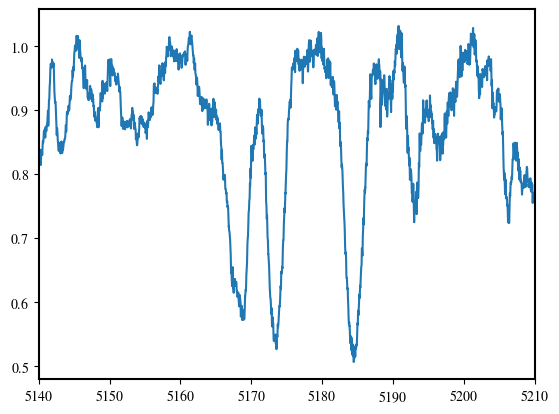

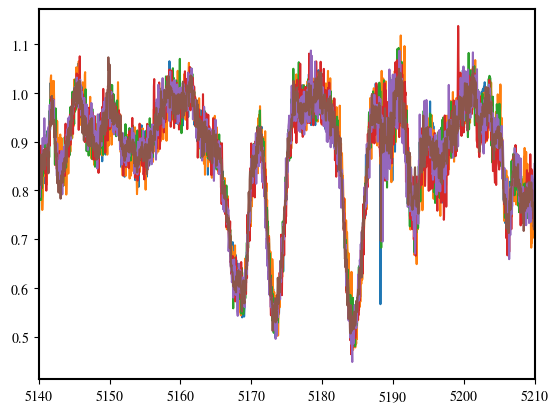

In [7]:
gaia_id_num = '3499149202247569536'

wave_obj, flux_obj, wave_all_obj, flux_all_obj, mjds = read_coadd(gaia_id_num, show = True, wave_range = [5140, 5210],
                                                                 norm_show=False)


# Comparing with GALAH spectra

In [8]:
def compute_chi2(file_path, feh, teff, logg, vsini, rv_grid, mask_waves, savgol_window = 25, const_snr = 100.0,
                noise_est_type = 'const_snr'):
    
    warnings.filterwarnings("ignore", category=AstropyWarning)
    
    wave_galah, flux_galah = get_galah_broadened(file_path, 0, vsini)

    wave_galah_norm, flux_galah_norm = median_norm(
        wave_galah, flux_galah,
        window_angs=10, top_mean=2,
        do_smooth=True
    )
    
    chi2_rv = []
    
    for rv in rv_grid:
        wave_galah_norm_shifted = wave_galah_norm * (1.0 + rv/3e5)

        normalized_flux_obj_select_interp = np.interp(
            wave_galah_norm_shifted,
            wave_obj_select,
            normalized_flux_obj_select
        )
        
        dilfact_interp = np.interp(wave_galah_norm_shifted, wd_dilfact_wave, wd_dilfact_fact)
        normalized_flux_obj_select_interp = dilfact_interp + (1.0 - dilfact_interp)*normalized_flux_obj_select_interp
        
        
        mask_emission = np.repeat(False, len(wave_galah_norm_shifted))
        for mw in mask_waves:
            mask_emission = mask_emission | ((wave_galah_norm_shifted < mw[1]) & (wave_galah_norm_shifted > mw[0]))
            
            
        if noise_est_type=='savgol':
            flux_obj_smooth = savgol_filter(normalized_flux_obj_select_interp, window_length=savgol_window, 
                                            polyorder=2)

            residuals = normalized_flux_obj_select_interp - flux_obj_smooth

            res = pd.Series(residuals)

            sigma_x = res.rolling(
                window=savgol_window,
                center=True,
                min_periods=savgol_window//2
            ).std()
            sigma2_arr = sigma_x**2
            
        else:
            sigma2_arr = normalized_flux_obj_select_interp/const_snr

        chi2 = np.nansum(
            (normalized_flux_obj_select_interp[~mask_emission] - flux_galah_norm[~mask_emission])**2
            / (sigma2_arr[~mask_emission])
        )
        
        chi2_rv.append(chi2)
        
    chi2_rv = np.array(chi2_rv)

    return np.min(chi2_rv), feh, teff, logg, vsini, rv_grid[np.argmin(chi2_rv)], file_path

wave_channel_dict = {'1':[4700, 4925],
                  '2':[5600, 5900],
                  '3':[6400, 6800]}

wave_channel = '1'


In [9]:
teffs = []
loggs = []
fehs = []
obj_ids = []
file_paths = []
ba_fes = []

## Load all the spectra for the channel of interest
galah_all_files = os.listdir('./galah_spectra_script/')
for gf in galah_all_files:
    galah_spec = fits.open('./galah_spectra_script/'+gf)
    if ('{}.fits'.format(wave_channel) in gf) and (galah_spec[0].header['LOGG']>=3.25):
        
        file_paths.append('./galah_spectra_script/'+gf)
        
        teffs.append(galah_spec[0].header['TEFF'])
        loggs.append(galah_spec[0].header['LOGG'])
        fehs.append(galah_spec[0].header['FE_H'])
        ba_fes.append(galah_spec[0].header['BA_FE'])
        
        
galah_table = Table.read("./galah_dr4_allstar_240705.fits")


In [13]:
warnings.filterwarnings("ignore", category=AstropyWarning)

wave_range = wave_channel_dict[wave_channel]

vsini_grid = np.arange(75, 95, 2)
rv_grid = np.arange(-300, 300.0, 1.0)

wave_obj_select, normalized_flux_obj_select, coelho_wave_norm_1, coelho_flux_norm_1 = read_and_display(wave_obj, flux_obj, './bosz_models_manual/r50000/m-0.25/bosz2024_mp_t5250_g+3.5_m-0.25_a+0.00_c+0.00_v0_r50000_resam.txt.gz', 
                     50.0, 60, nf = 1.0, wave_range = wave_range, model = 'none', show = False)

mask_waves = [[6540, 6590], [4850, 4856.5], [4700, 4718], [4898, 5000]]

jobs = []

for i, file_path in enumerate(file_paths):
    
    for vsini in vsini_grid:
        jobs.append(
            (file_path, fehs[i], teffs[i], loggs[i], vsini, rv_grid, mask_waves)
        )

results = Parallel(
    n_jobs=8,
    backend="loky",     # safest backend for numpy/scipy
    verbose=0
)(
    delayed(compute_chi2)(*job)
    for job in jobs
)

chi2_arr, feh_arr, teff_arr, logg_arr, vsini_arr, rv_arr, fp_arr = map(list, zip(*results))

chi2_arr = np.array(chi2_arr)
feh_arr = np.array(feh_arr)
teff_arr = np.array(teff_arr)
logg_arr = np.array(logg_arr)
vsini_arr = np.array(vsini_arr)
rv_arr = np.array(rv_arr)
fp_arr = np.array(fp_arr)


In [14]:
'''
Select the unique files, i.e. take the fit corresponding to the best vsini/RV for a given template
'''
unique_specs = list(set(fp_arr))

chi2_unique_us = []
teff_unique_us = []
feh_unique_us = []
vsini_unique_us = []
logg_unique_us = []

for us in unique_specs:
    select_us = fp_arr==us
    
    index = np.argmin(chi2_arr[select_us])
    
    chi2_unique_us.append(chi2_arr[select_us][index])
    teff_unique_us.append(teff_arr[select_us][index])
    feh_unique_us.append(feh_arr[select_us][index])
    vsini_unique_us.append(vsini_arr[select_us][index])
    logg_unique_us.append(logg_arr[select_us][index])
    
chi2_unique_us = np.array(chi2_unique_us)
teff_unique_us = np.array(teff_unique_us)
feh_unique_us = np.array(feh_unique_us)
vsini_unique_us = np.array(vsini_unique_us)
logg_unique_us = np.array(logg_unique_us)

In [15]:
'''
Get the average/std for the top 20 templates
'''
def first_n_indices(arr, N):
    return np.argsort(arr)[:N]

idx = first_n_indices(chi2_unique_us, 20)

print('With first 20')
print(np.mean(feh_unique_us[idx]), np.std(feh_unique_us[idx]))
print(np.mean(vsini_unique_us[idx]), np.std(vsini_unique_us[idx]))
print(np.mean(teff_unique_us[idx]), np.std(teff_unique_us[idx]))
print(np.mean(logg_unique_us[idx]), np.std(logg_unique_us[idx]))

With first 20
0.09776311565 0.04108103963196727
83.6 1.42828568570857
4994.404639999999 63.466442708642575
3.39448651 0.09781315150689046


## Making the plot

Text(0.3, 0.87, 'Ba II $\\mathbf{6141~\\rm\\AA}$')

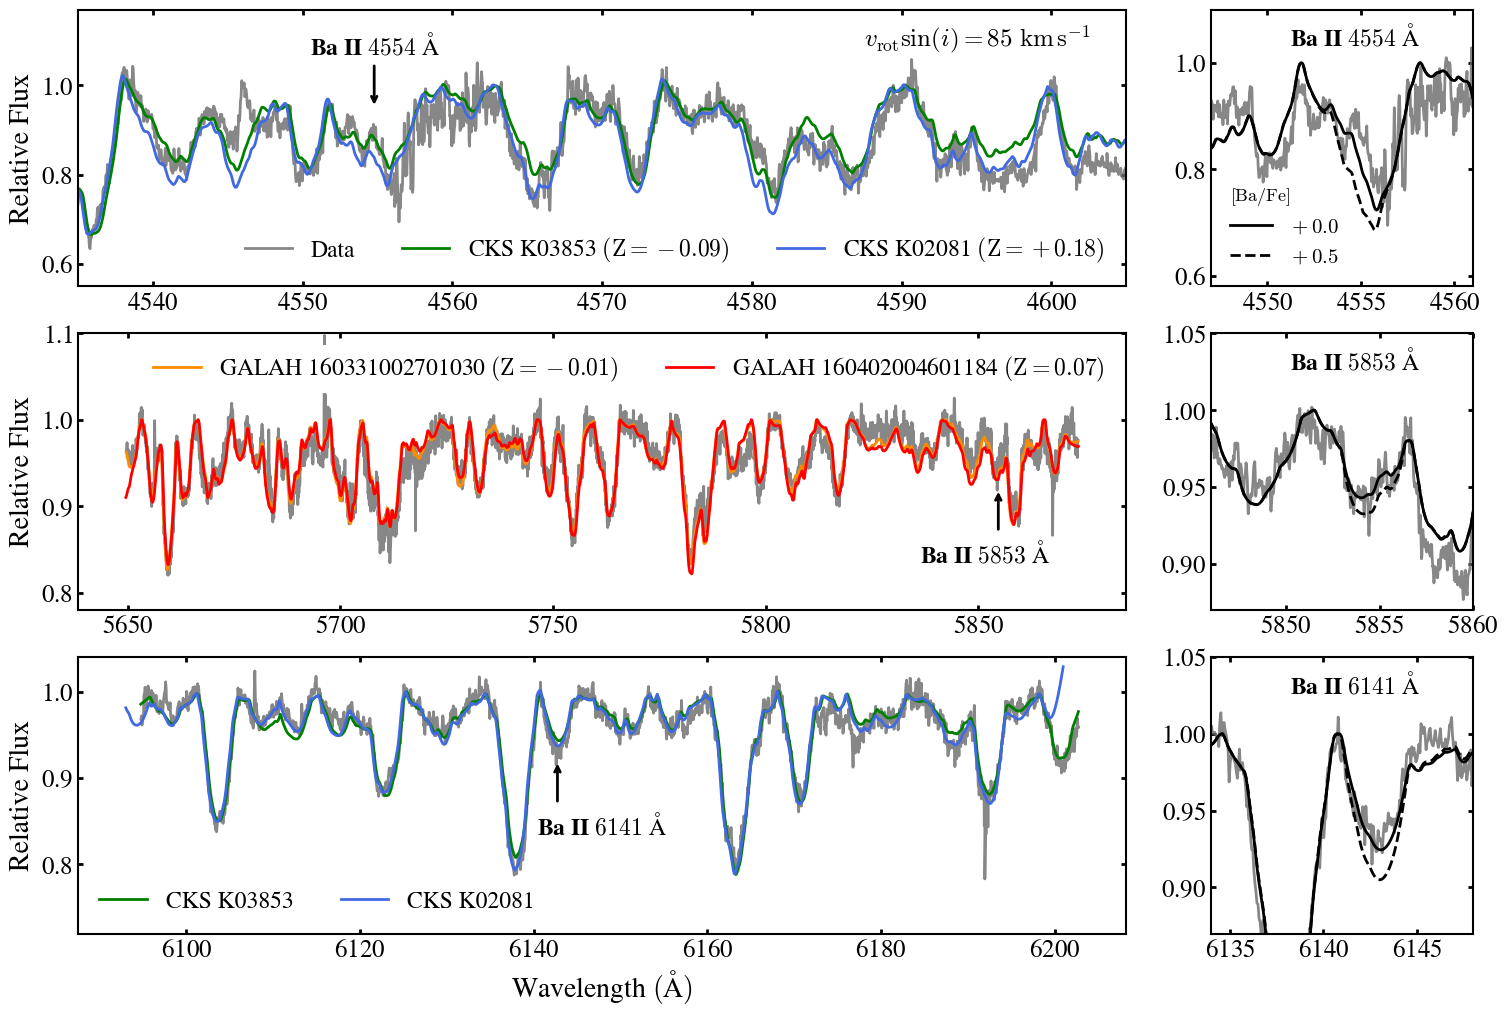

In [17]:
fig = plt.figure(figsize=(18, 12))

gs = GridSpec(
    3, 2,
    figure=fig,
    width_ratios=[4, 1],   # left wide, right narrow (adjustable)
    wspace=0.13,           # horizontal separation
    hspace=0.17            # vertical separation
)

# Left column axes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])

# Right column axes (smaller)
ax1_r = fig.add_subplot(gs[0, 1])
ax2_r = fig.add_subplot(gs[1, 1])
ax3_r = fig.add_subplot(gs[2, 1])

ba_closeup_wv_window = 7

parent_dir = os.path.expanduser(
    './iSpec_v20230804/'
)

wave_arr = np.arange(450.0, 650.0, 0.001)*10 * (1.0 + 51/3e5)
ispec_file = fits.open(parent_dir + 'mh-0.1_bafe+0.0_synth_spectrum.fits')
flux_synspec_full = ispec_file[0].data

ispec_file = fits.open(parent_dir + 'mh-0.1_bafe+0.5_synth_spectrum.fits')
flux_synspec_full_ba = ispec_file[0].data


'''
'''

######
# First Ba line
######

order = 19
cks_wave, cks_flux = get_cks_broadened('./cks/cks-k03853_bj178.124.fits', 140, 85, order = order)
cks_wave1, cks_flux1 = get_cks_broadened('./cks/cks-k02081_bj179.690.fits', 51, 85, order = order)

wave_range = [min(cks_wave1), max(cks_wave1)]

wave_obj_select, normalized_flux_obj_select, coelho_wave_norm, coelho_flux_norm = read_and_display(wave_obj, flux_obj, './bosz_models_manual/r50000/m+0.25/bosz2024_mp_t5000_g+3.5_m+0.25_a+0.00_c+0.00_v0_r50000_resam.txt.gz', 
                     51.0, 85, nf=1.0, wave_range = wave_range, model = 'none', show = False)
ax1.plot(wave_obj_select, normalized_flux_obj_select, c='dimgray', alpha = 0.8, label = 'Data', linewidth = 2.0)

wave_cks_norm, flux_cks_norm = median_norm(cks_wave, cks_flux, 
                                                             window_angs=15, top_mean=20, do_smooth=True)
ax1.plot(wave_cks_norm, flux_cks_norm - 0.007, c='green', linewidth = 2.0, label = r'CKS K03853 $\rm (Z=-0.09)$')

wave_cks_norm1, flux_cks_norm1 = median_norm(cks_wave1, cks_flux1, 
                                                             window_angs=15, top_mean=20, do_smooth=True)
ax1.plot(wave_cks_norm1, flux_cks_norm1 - 0.007, c='royalblue', linewidth = 2.0, label = r'CKS K02081 $\rm (Z=+0.18)$')

ax1.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2, labelleft=True)

ax1.set_ylabel(r'Relative Flux', fontsize = 20)

ax1.set_ylim(0.55, 1.17)
ax1.set_xlim(4535, 4605)

baii_wave = 4554*(1+51/3e5)

ax1.annotate(
    '', 
    xy=(baii_wave, 0.95),      # arrow tip (bottom)
    xytext=(baii_wave, 1.05),  # arrow start (top)
    arrowprops=dict(
        arrowstyle='->',
        color='k',
        linewidth=2
    )
)

ax1.text(baii_wave-4.3, 1.07, r'Ba II $\mathbf{4554~\rm\AA}$', c='k', fontsize = 17, fontweight = 'bold')

ax1.legend(ncols = 3, fontsize = 17, loc = 'lower right', framealpha = 0.0)


## Ba closeup
ax1_r.plot(wave_obj_select, normalized_flux_obj_select, c='dimgray', alpha = 0.8, linewidth = 2.0)
ax1_r.set_xlim(4554 - ba_closeup_wv_window, 4554 + ba_closeup_wv_window)

select = (wave_arr<4654) & (wave_arr>4454)
wave_synspec = wave_arr[select]
flux_synspec = flux_synspec_full[select]
flux_synspec = pyasl.rotBroad(wave_synspec, flux_synspec, 0.5, 85)

wave_synspec, flux_synspec = median_norm(wave_synspec, flux_synspec, do_smooth=False,window_angs = 10,
                                        top_mean=2)
ax1_r.plot(wave_synspec, flux_synspec, c='k', linewidth = 2.0, label = r'$\rm +0.0$')


flux_synspec = flux_synspec_full_ba[select]
flux_synspec = pyasl.rotBroad(wave_synspec, flux_synspec, 0.5, 85)

wave_synspec, flux_synspec = median_norm(wave_synspec, flux_synspec, do_smooth=False,window_angs = 10,
                                        top_mean=2)
ax1_r.plot(wave_synspec, flux_synspec, c='k', linewidth = 2.0, linestyle = '--', label = r'$\rm +0.5$')

ax1_r.set_ylim(0.58, 1.1)

ax1_r.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2, labelleft=True)

leg = ax1_r.legend(loc = 'lower left', fontsize = 15, title=r"$\rm [Ba/Fe]$", ncols = 1,
                  framealpha = 0.0)
leg.get_title().set_fontsize(13)
leg._legend_box.align = "left"

######
# Second GALAH 2 line
######

filename = './galah_spectra_script/1603310027010302.fits' ## Good one
wave_galah, flux_galah = get_galah_broadened(filename, 21, 85)

wave_galah_norm, flux_galah_norm = median_norm(wave_galah, flux_galah, 
                                                             window_angs=12, top_mean=2)

wave_range = [min(wave_galah_norm), max(wave_galah_norm)]

wave_obj_select, normalized_flux_obj_select, coelho_wave_norm, coelho_flux_norm = read_and_display(wave_obj, flux_obj, './bosz_models_manual/r50000/m+0.25/bosz2024_mp_t5000_g+3.5_m+0.25_a+0.00_c+0.00_v0_r50000_resam.txt.gz', 
                     30.0, 85, nf=1.0, wave_range = wave_range, model = 'none', show = False)

ax2.plot(wave_obj_select, normalized_flux_obj_select, c='dimgray', alpha = 0.8, linewidth = 2.0)
ax2.plot(wave_galah_norm, flux_galah_norm, c='darkorange', linewidth = 2.0, label = r'GALAH 160331002701030 $(\rm Z=-0.01)$', zorder = 100)


filename = './galah_spectra_script/1604020046011842.fits' ## Good
wave_galah, flux_galah = get_galah_broadened(filename, 34, 85)

wave_galah_norm, flux_galah_norm = median_norm(wave_galah, flux_galah, 
                                                             window_angs=12, top_mean=2)
ax2.plot(wave_galah_norm, flux_galah_norm, c='red', linewidth = 2.0, label = r'GALAH 160402004601184 $(\rm Z=0.07)$', zorder = 100)


ax2.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2, labelleft=True)
ax2.set_ylabel(r'Relative Flux', fontsize = 20)
ax2.set_ylim(0.78, 1.1)

leg = ax2.legend(ncols = 3, fontsize = 17, loc = 'upper right', framealpha = 1.0)
leg.get_frame().set_edgecolor('none')
#ax2.set_xlim(5651, 5865)

baii_wave = 5853.7 * (1+51/3e5)
ax2.annotate(
    '', 
    xy=(baii_wave, 0.92),      # arrow tip (bottom)
    xytext=(baii_wave, 0.87),  # arrow start (top)
    arrowprops=dict(
        arrowstyle='->',
        color='k',
        linewidth=2
    )
)

ax2.text(baii_wave-18.3, 0.835, r'Ba II $\mathbf{5853~\rm\AA}$', c='k', fontsize = 17, fontweight = 'bold')

## Ba closeup
ax2_r.plot(wave_obj_select, normalized_flux_obj_select, c='dimgray', alpha = 0.8, label = 'Data', linewidth = 2.0)
ax2_r.set_xlim(5853 - ba_closeup_wv_window, 5853 + ba_closeup_wv_window)


select = (wave_arr<5953) & (wave_arr>5753)
wave_synspec = wave_arr[select]
flux_synspec = flux_synspec_full[select]
flux_synspec = pyasl.rotBroad(wave_synspec, flux_synspec, 0.5, 85)

wave_synspec, flux_synspec = median_norm(wave_synspec, flux_synspec, do_smooth=False,window_angs = 10,
                                        top_mean=2)
ax2_r.plot(wave_synspec, flux_synspec, c='k', linewidth = 2.0)


flux_synspec = flux_synspec_full_ba[select]
flux_synspec = pyasl.rotBroad(wave_synspec, flux_synspec, 0.5, 85)

wave_synspec, flux_synspec = median_norm(wave_synspec, flux_synspec, do_smooth=False,window_angs = 10,
                                        top_mean=2)
ax2_r.plot(wave_synspec, flux_synspec, c='k', linewidth = 2.0, linestyle = '--')

ax2_r.set_ylim(0.87, 1.05)

ax2_r.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2, labelleft=True)

######
# Second CKS line
######

order = 13
cks_wave, cks_flux = get_cks_broadened('./cks/cks-k03853_rj178.124.fits', 140, 85, order = order)
cks_wave1, cks_flux1 = get_cks_broadened('./cks/cks-k02081_rj179.690.fits', 55, 85, order = order)

wave_range = [min(cks_wave), max(cks_wave)]

wave_obj_select, normalized_flux_obj_select, coelho_wave_norm_1, coelho_flux_norm_1 = read_and_display(wave_obj, flux_obj, './bosz_models_manual/r50000/m-0.25/bosz2024_mp_t5250_g+3.5_m-0.25_a+0.00_c+0.00_v0_r50000_resam.txt.gz', 
                     50.0, 60, nf=1.0, wave_range = wave_range, model = 'none', show = False)
ax3.plot(wave_obj_select, normalized_flux_obj_select, c='dimgray', alpha = 0.8, linewidth = 2.0)

wave_cks_norm, flux_cks_norm = median_norm(cks_wave, cks_flux, 
                                                             window_angs=10, top_mean=20, do_smooth=True)
ax3.plot(wave_cks_norm, flux_cks_norm - 0.007, c='green', linewidth = 2.0, label = r'CKS K03853')

wave_cks_norm1, flux_cks_norm1 = median_norm(cks_wave1, cks_flux1, 
                                                             window_angs=10, top_mean=20, do_smooth=True)
ax3.plot(wave_cks_norm1, flux_cks_norm1 - 0.007, c='royalblue', linewidth = 2.0, label = r'CKS K02081')

ax3.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2, labelleft=True)
ax3.set_ylabel(r'Relative Flux', fontsize = 20)
ax3.set_xlabel(r'Wavelength $\rm(\AA)$', fontsize = 20)
ax3.set_ylim(0.72, 1.04)

ax3.legend(ncols = 3, fontsize = 17, framealpha = 0)

baii_wave = 6141.7 * (1+51/3e5)
ax3.annotate(
    '', 
    xy=(baii_wave, 0.92),      # arrow tip (bottom)
    xytext=(baii_wave, 0.87),  # arrow start (top)
    arrowprops=dict(
        arrowstyle='->',
        color='k',
        linewidth=2
    )
)

ax3.text(baii_wave-2.3, 0.835, r'Ba II $\mathbf{6141~\rm\AA}$', c='k', fontsize = 17, fontweight = 'bold')

## Ba closeup
ax3_r.plot(wave_obj_select, normalized_flux_obj_select, c='dimgray', alpha = 0.8, label = 'Data', linewidth = 2.0)
ax3_r.set_xlim(6141 - ba_closeup_wv_window, 6141 + ba_closeup_wv_window)


select = (wave_arr<6241) & (wave_arr>6041)
wave_synspec = wave_arr[select]
flux_synspec = flux_synspec_full[select]
flux_synspec = pyasl.rotBroad(wave_synspec, flux_synspec, 0.5, 85)

wave_synspec, flux_synspec = median_norm(wave_synspec, flux_synspec, do_smooth=False,window_angs = 10,
                                        top_mean=2)
ax3_r.plot(wave_synspec, flux_synspec, c='k', linewidth = 2.0)


flux_synspec = flux_synspec_full_ba[select]
flux_synspec = pyasl.rotBroad(wave_synspec, flux_synspec, 0.5, 85)

wave_synspec, flux_synspec = median_norm(wave_synspec, flux_synspec, do_smooth=False,window_angs = 10,
                                        top_mean=2)
ax3_r.plot(wave_synspec, flux_synspec, c='k', linewidth = 2.0, linestyle = '--')

ax3_r.set_ylim(0.87, 1.05)

ax3_r.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2, labelleft=True)

ax1.text(0.75, 0.87, r'$v_{\rm rot}\sin(i)=85~\rm km\,s^{-1}$', fontsize = 18, transform=ax1.transAxes)


ax1_r.text(0.3, 0.87, 
          r'Ba II $\mathbf{4554~\rm\AA}$', c='k', fontsize = 17, fontweight = 'bold', transform=ax1_r.transAxes)
ax2_r.text(0.3, 0.87, 
          r'Ba II $\mathbf{5853~\rm\AA}$', c='k', fontsize = 17, fontweight = 'bold', transform=ax2_r.transAxes)
ax3_r.text(0.3, 0.87, 
          r'Ba II $\mathbf{6141~\rm\AA}$', c='k', fontsize = 17, fontweight = 'bold', transform=ax3_r.transAxes)


#plt.savefig("./plots/a35_paper_plots/spectrum_comparison.png",dpi=200,bbox_inches='tight')


## Comparing with iSpec SPECTRUM Models

In [299]:
from astropy.io import fits
import numpy as np
from joblib import Parallel, delayed


wave_range = [6075, 6180]

wave_obj_select, normalized_flux_obj_select, coelho_wave_norm, coelho_flux_norm = read_and_display(wave_obj, flux_obj, './bosz_models_manual/r50000/m+0.25/bosz2024_mp_t5000_g+3.5_m+0.25_a+0.00_c+0.00_v0_r50000_resam.txt.gz', 
                     51.0, 85, nf=1.0, wave_range = wave_range, model = 'bosz', show = False)


savgol_window = 20
flux_obj_smooth = savgol_filter(normalized_flux_obj_select, window_length=savgol_window, 
                                            polyorder=2)

residuals = normalized_flux_obj_select - flux_obj_smooth

res = pd.Series(residuals)

sigma_x = res.rolling(
    window=savgol_window,
    center=True,
    min_periods=savgol_window//2
).std()
sigma2_arr = sigma_x**2


parent_dir = os.path.expanduser(
    './iSpec_v20230804/example_grid_spectrum/grid/'
)

ispec_files = os.listdir(parent_dir)

rv_grid = np.arange(43.0, 53.0, 1)
vsini_grid = np.arange(75.0, 95.0, 1.5)

wave_synspec = np.arange(450, 650, 0.003)*10

def process_ispec_file(file):
    parts = file.split('_')
    teff = float(parts[0])
    mh   = float(parts[2])
    alpha = float(parts[3])

    ispec_hdul = fits.open(parent_dir + file)

    select = (wave_synspec < wave_range[1] + 50) & \
             (wave_synspec > wave_range[0] - 50)

    ispec_data = ispec_hdul[0].data[select]
    ispec_wave = wave_synspec[select]

    local_rmss  = []
    local_teffs = []
    local_mhs   = []
    local_vsinis   = []
    local_rvs   = []
    local_files = []
    local_alphas = []

    for vsini in vsini_grid:
        ispec_data_broadened = pyasl.rotBroad(
            ispec_wave, ispec_data, 0.6, vsini
        )

        ispec_wave_norm, ispec_data_broadened_norm = median_norm(
            ispec_wave,
            ispec_data_broadened,
            do_smooth=False,
            window_angs=12,
            top_mean=7
        )

        for rv in rv_grid:
            ispec_wave_norm_shifted = ispec_wave_norm * (1.0 + rv / 3e5)

            ispec_interp = np.interp(
                wave_obj_select,
                ispec_wave_norm_shifted,
                ispec_data_broadened_norm
            )

            rms = np.sum(
                ((normalized_flux_obj_select - ispec_interp) ** 2)/sigma2_arr
            )

            local_rmss.append(rms)
            local_teffs.append(teff)
            local_mhs.append(mh)
            local_vsinis.append(vsini)
            local_rvs.append(rv)
            local_files.append(file)
            local_alphas.append(alpha)

    return local_rmss, local_teffs, local_mhs, local_vsinis, local_rvs, local_files, local_alphas

results = Parallel(n_jobs=10, backend="loky")(
    delayed(process_ispec_file)(file)
    for file in ispec_files
)

rmss, teffs, mhs, vsinis, rvs, files, alphas = [], [], [], [], [], [], []

for r, t, m, vs, rv, f, a in results:
    rmss.extend(r)
    teffs.extend(t)
    mhs.extend(m)
    vsinis.extend(vs)
    rvs.extend(rv)
    files.extend(f)
    alphas.extend(a)
    
rmss = np.array(rmss)
teffs = np.array(teffs)
mhs = np.array(mhs)
vsinis = np.array(vsinis)
rvs = np.array(rvs)
files = np.array(files)
alphas = np.array(alphas)


In [301]:
unique_files = list(set(files))

unique_mhs = []
unique_teffs = []
unique_vsinis = []
unique_rvs = []
unique_rmss = []
unique_alphas = []

for uf in unique_files:
    
    select_uf = files == uf
    
    index = np.argmin(rmss[select_uf])
    
    unique_teffs.append(teffs[select_uf][index])
    unique_vsinis.append(vsinis[select_uf][index])
    unique_mhs.append(mhs[select_uf][index])
    unique_rvs.append(rvs[select_uf][index])
    unique_rmss.append(rmss[select_uf][index])
    unique_alphas.append(alphas[select_uf][index])
    
unique_mhs = np.array(unique_mhs)
unique_teffs = np.array(unique_teffs)
unique_vsinis = np.array(unique_vsinis)
unique_rvs = np.array(unique_rvs)
unique_rmss = np.array(unique_rmss)
unique_alphas = np.array(unique_alphas)

idx20 = np.argsort(unique_rmss)[:20]
print(wave_range)
print(np.mean(unique_mhs[idx20]), np.std(unique_mhs[idx20]))
print(np.mean(unique_teffs[idx20]), np.std(unique_teffs[idx20]))
print(np.mean(unique_vsinis[idx20]), np.std(unique_vsinis[idx20]))
print(np.mean(unique_rvs[idx20]), np.std(unique_rvs[idx20]))
print(np.mean(unique_alphas[idx20]), np.std(unique_alphas[idx20]))


[6075, 6180]
-0.08249999999999999 0.09120718173477349
4787.5 58.89609494694873
90.15 3.6093628246547893
47.0 0.31622776601683794
0.06000000000000001 0.04898979485566356


## ISM Eb-v using Na D lines

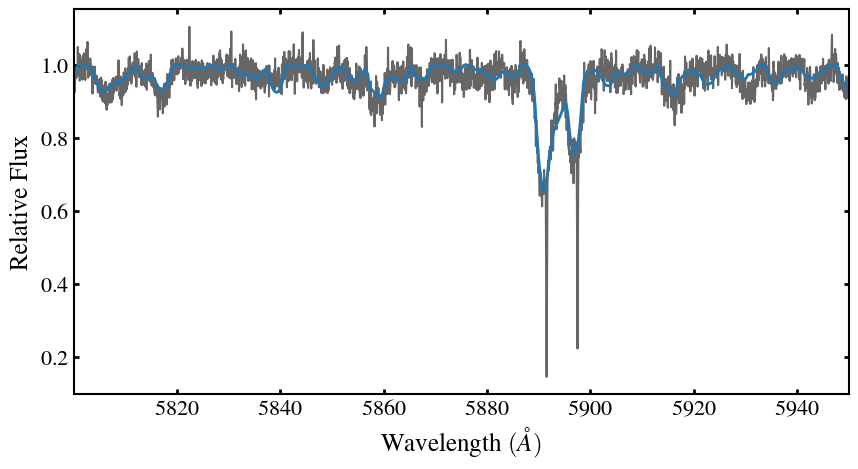

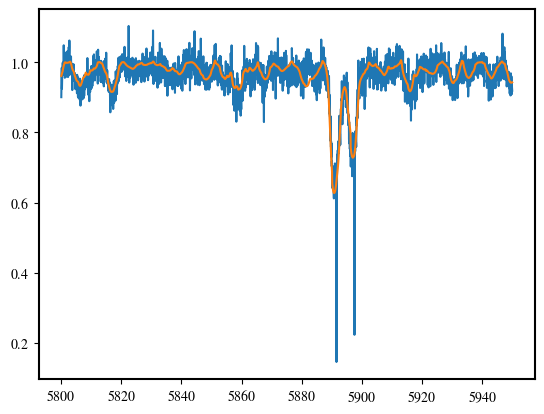

In [81]:
wave_obj_select, normalized_flux_obj_select, coelho_wave_norm, coelho_flux_norm = read_and_display(wave_all_obj[3], flux_all_obj[3], './bosz_models_manual/r50000/m+0.00/bosz2024_mp_t5000_g+3.5_m+0.00_a+0.00_c+0.00_v0_r50000_resam.txt.gz', 
                     50.0, 85, nf = 1.0, wave_range = [5800, 5950], model = 'bosz')

filename = './galah_spectra_script/1603310027010302.fits'
wave_galah, flux_galah = get_galah_broadened(filename, 21, 85)

wave_galah_norm, flux_galah_norm = median_norm(wave_galah, flux_galah, 
                                                             window_angs=12, top_mean=2)

## Coadd the two orders over which the NaD lines appear in CKS
cks_wave1, cks_flux1 = get_cks_broadened('./cks/cks-k02081_rj179.690.fits', 63, 100, order = 10)
wave_cks_norm1, flux_cks_norm1 = median_norm(cks_wave1, cks_flux1, 
                                                             window_angs=10, top_mean=2, do_smooth=True)

cks_wave, cks_flux = get_cks_broadened('./cks/cks-k02081_rj179.690.fits', 63, 100, order = 11)
wave_cks_norm, flux_cks_norm = median_norm(cks_wave, cks_flux, 
                                                             window_angs=10, top_mean=2, do_smooth=True)


coelho_flux_norm_interp = np.interp(wave_obj_select, coelho_wave_norm, coelho_flux_norm)
galah_norm_interp = np.interp(wave_obj_select, wave_galah_norm, flux_galah_norm)
cks_norm_interp = np.interp(wave_obj_select, wave_cks_norm, flux_cks_norm, left = 0, right = 0)
cks_norm_interp1 = np.interp(wave_obj_select, wave_cks_norm1, flux_cks_norm1, left = 0, right = 0)

norm_arr = ((cks_norm_interp!=0) + 0.0) + ((cks_norm_interp1!=0) + 0.0)
norm_arr[norm_arr==0]=1.0

cks_norm_coadd = (cks_norm_interp + cks_norm_interp1)/norm_arr


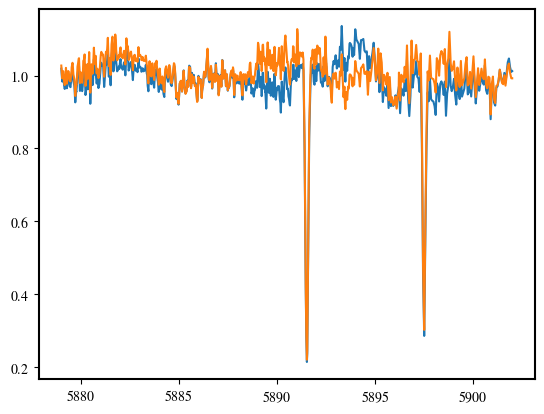

In [117]:
## Normalize the fux with the model

select = (wave_obj_select<5902) & (wave_obj_select>5879)

wave_fit = wave_obj_select[select]
flux_fit1 = normalized_flux_obj_select[select] / coelho_flux_norm_interp[select]
flux_fit2 = normalized_flux_obj_select[select] / cks_norm_coadd[select]

flux_fit = (flux_fit1+flux_fit2)/2


In [145]:
import numpy as np
from scipy.optimize import curve_fit

# --- Model: continuum (1.0) + two negative Gaussians ---
def two_gauss(x, A1, mu1, sigma1, A2, mu2, sigma2):
    g1 = A1 * np.exp(-(x - mu1)**2 / (2*sigma1**2))
    g2 = A2 * np.exp(-(x - mu2)**2 / (2*sigma2**2))
    return 1.0 + g1 + g2

# --- Initial guesses ---
p0 = [-0.3, 5891.5, 0.5,
      -0.3, 5897.5, 0.5]

# --- Fit ---
popt, pcov = curve_fit(two_gauss, wave_fit, flux_fit, p0=p0)

A1, mu1, sigma1, A2, mu2, sigma2 = popt

# --- Compute areas of the Gaussians (absolute EW-like area) ---
# Area of A * exp(-(x-mu)^2/(2σ^2)) = A * sigma * sqrt(2π)
area1 = abs(A1 * sigma1 * np.sqrt(2*np.pi))
area2 = abs(A2 * sigma2 * np.sqrt(2*np.pi))

total_area = area1 + area2

print("Best-fit parameters:")
print(f"A1={A1}, mu1={mu1}, sigma1={sigma1}")
print(f"A2={A2}, mu2={mu2}, sigma2={sigma2}")
print()
print("Area under Gaussian 1:", area1)
print("Area under Gaussian 2:", area2)
print("Total absolute area:", total_area)


Best-fit parameters:
A1=-0.7929025746572671, mu1=5891.522289776531, sigma1=-0.0673713621615129
A2=-0.6809630984968397, mu2=5897.5020134087235, sigma2=0.06888886175647765

Area under Gaussian 1: 0.1339013916055184
Area under Gaussian 2: 0.11758786936899203
Total absolute area: 0.2514892609745104


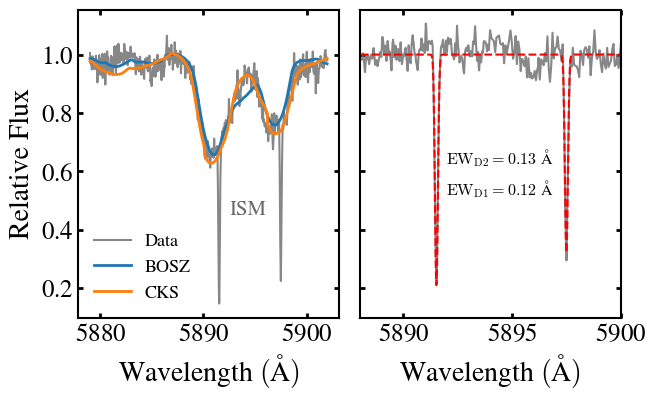

In [175]:
fig = plt.figure(figsize=(7, 4))

gs = GridSpec(
    nrows=1, ncols=2,
    width_ratios=[1, 1],   # adjust if needed
    wspace=0.08            # horizontal spacing
)

ax_left  = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[1], sharey=ax_left)

wave_arr_fit_plot = np.linspace(5885, 5902, 1000)
fit_model = two_gauss(wave_arr_fit_plot, *popt)

select = (wave_obj_select<5902) & (wave_obj_select>5879)

ax_left.plot(wave_obj_select[select], normalized_flux_obj_select[select], label = 'Data', c='dimgray',
            linewidth = 1.5, alpha = 0.8)
ax_left.plot(wave_obj_select[select], coelho_flux_norm_interp[select], linewidth = 2, label = 'BOSZ')
ax_left.plot(wave_obj_select[select], cks_norm_coadd[select], linewidth = 2, label = 'CKS')
ax_left.legend(loc = 'lower left', ncols = 1, framealpha = 0.0, fontsize = 13)
ax_left.text(5892.5, 0.45, 'ISM', fontsize = 15, c='dimgray')


ax_right.plot(wave_obj_select[select], flux_fit, c='dimgray', linewidth = 1.5, alpha = 0.8, label = 'Normalized Data')
ax_right.plot(wave_arr_fit_plot, fit_model, c='red', linestyle = '--')
ax_right.set_xlim(5888, 5900)
#ax_right.legend(loc = 'lower center', ncols = 1, framealpha = 0.0, fontsize = 13)

ax_right.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2, labelleft=False)
ax_left.tick_params(which='both',direction='in',top=True,right=True,labelsize=18,labelbottom = True, width=2, labelleft=True)

ax_right.text(0.33, 0.5, r'$\rm EW_{{\rm D2}}={}~\AA$'.format(round(area1,2)), transform=ax_right.transAxes,
             fontsize = 11.5)
ax_right.text(0.33, 0.4, r'$\rm EW_{{\rm D1}}={}~\AA$'.format(round(area2,2)), transform=ax_right.transAxes,
             fontsize = 11.5)

ax_left.set_ylabel('Relative Flux', fontsize = 20)
ax_left.set_xlabel(r'Wavelength $\rm(\AA)$', fontsize = 20)
ax_right.set_xlabel(r'Wavelength $\rm(\AA)$', fontsize = 20)

plt.savefig("./plots/a35_paper_plots/nad_reddening.png",dpi=200,bbox_inches='tight')


In [161]:
'''
Estimating Eb-v using Poznanski+12
'''

## Total

logebv_na1 = 1.17*total_area-1.85

logebv_na1_random = np.random.normal(logebv_na1, 0.08, 5000)
ebv_random = 10**(logebv_na1_random)

print(np.mean(ebv_random), np.quantile(ebv_random, 0.16), np.quantile(ebv_random, 0.84))

## D2

logebv_na1 = 2.16*area1-1.91

logebv_na1_random = np.random.normal(logebv_na1, 0.15, 5000)
ebv_random = 10**(logebv_na1_random)

print(np.mean(ebv_random), np.quantile(ebv_random, 0.16), np.quantile(ebv_random, 0.84))

## D1

logebv_na1 = 2.47*area2-1.76

logebv_na1_random = np.random.normal(logebv_na1, 0.17, 5000)
ebv_random = 10**(logebv_na1_random)

print(np.mean(ebv_random), np.quantile(ebv_random, 0.16), np.quantile(ebv_random, 0.84))

0.028234102808830742 0.023135809890682466 0.03341633672242842
0.025345499108582543 0.016673359074374394 0.03390494224761095
0.03694133759386334 0.022818746863755263 0.05042179931375387
